06 - CNN Model (Deep Learning Model)

## Setup
Run the cell below first. It detects whether you're in **Google Colab** or
running **locally in VS Code**, and gets the environment ready either way
(clones the repo in Colab, installs requirements, downloads NLTK data, and
adds `src/` to the path so `pipeline.py` can be imported).

In [1]:
# ============================================================
# SETUP CELL - run this first, every time
# Works both locally (VS Code / Jupyter) and in Google Colab
# ============================================================
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/Sandaru17513/NLP_Ctrl-Alt-Elite.git"
    REPO_DIR = "NLP_Ctrl-Alt-Elite"

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL}")
    os.chdir(f"{REPO_DIR}/notebooks")

    get_ipython().system("pip install -q -r ../requirements.txt")

    # Data files are large - if they were not committed to the repo,
    # upload them here once per Colab session.
    if not os.path.exists("../data/data.csv"):
        print("data/data.csv not found in the cloned repo.")
        print("Option A: git add + commit + push the CSVs from your")
        print("          local machine so they come down with the clone.")
        print("Option B: uncomment the lines below to upload manually.")
        # from google.colab import files
        # uploaded = files.upload()   # select data.csv + validation_dataset.csv
        # os.makedirs("../data", exist_ok=True)
        # for fname in uploaded:
        #     os.rename(fname, f"../data/{fname}")
else:
    print("Running locally (VS Code / Jupyter). Using existing .venv environment.")

import nltk
for pkg in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

sys.path.append(os.path.abspath("../src"))
print("IN_COLAB =", IN_COLAB)
print("Working directory:", os.getcwd())


Cloning into 'NLP_Ctrl-Alt-Elite'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 133 (delta 8), reused 32 (delta 3), pack-reused 88 (from 1)
Receiving objects: 100% (133/133), 70.80 MiB | 16.87 MiB/s, done.
Resolving deltas: 100% (37/37), done.
data/data.csv not found in the cloned repo.
Option A: git add + commit + push the CSVs from your
          local machine so they come down with the clone.
Option B: uncomment the lines below to upload manually.
IN_COLAB = True
Working directory: /content/NLP_Ctrl-Alt-Elite/notebooks


In [2]:
import os

data_dir = '../data/'

if os.path.exists(data_dir):
    print(f"Directory '{data_dir}' exists.")
    print("Contents of '../data/':")
    for item in os.listdir(data_dir):
        print(f"- {item}")
else:
    print(f"Directory '{data_dir}' does NOT exist.")


Directory '../data/' exists.
Contents of '../data/':
- .gitkeep
- dataset.csv
- validation_dataset.csv


In [3]:
import pandas as pd

# Load dataset.csv
df_dataset = pd.read_csv('../data/dataset.csv')

print("Columns in dataset.csv:")
print(df_dataset.columns.tolist())

print("\nFirst 5 rows of dataset.csv:")
display(df_dataset.head())

Columns in dataset.csv:
['label', 'text']

First 5 rows of dataset.csv:


,label,text
0,1,Congratulations! You've been selected for a lu...
1,1,URGENT: Your account has been compromised. Cli...
2,1,You've won a free iPhone! Claim your prize by ...
3,1,Act now and receive a 50% discount on all purc...
4,1,Important notice: Your subscription will expir...


### Prepare text sequences

In [4]:
import os

src_dir = os.path.abspath('../src/')

if os.path.exists(src_dir):
    print(f"Directory '{src_dir}' exists.")
    print("Contents of '../src/':")
    for item in os.listdir(src_dir):
        print(f"- {item}")
    if 'pipeline.py' not in os.listdir(src_dir):
        print("Warning: 'pipeline.py' not found in '../src/'.")
else:
    print(f"Directory '{src_dir}' does NOT exist.")


Directory '/content/NLP_Ctrl-Alt-Elite/src' exists.
Contents of '../src/':
- .gitkeep
- cit-24-01-0182


In [5]:
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

src_dir = '../src'
os.makedirs(src_dir, exist_ok=True)

pipeline_content = '''
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Ensure NLTK data is downloaded (though the setup cell should handle this)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_and_lemmatize(text):
    if not isinstance(text, str): # Handle non-string inputs gracefully
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\\s]', '', text) # Remove punctuation and numbers
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    lemmas = [lemmatizer.lemmatize(word) for word in filtered_tokens]
    return ' '.join(lemmas)
'''

pipeline_file_path = os.path.join(src_dir, 'pipeline.py')
with open(pipeline_file_path, 'w') as f:
    f.write(pipeline_content)

print(f"Created '{pipeline_file_path}' successfully.")
print("You can now re-run the cell containing the model setup (cell 8bb26fac).")


Created '../src/pipeline.py' successfully.
You can now re-run the cell containing the model setup (cell 8bb26fac).


In [6]:
import numpy as np
import pandas as pd
import joblib
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import sys
sys.path.append(os.path.abspath('../src'))
from pipeline import tokenize_and_lemmatize # Import here, needed for preprocessing

# --- Process main dataset (dataset.csv) ---
print("Processing ../data/dataset.csv...")
df = pd.read_csv('../data/dataset.csv')
# Assuming 'label' column is 0 for ham and 1 for spam
# And 'text' column needs to be processed into 'final_text'
df['final_text'] = df['text'].apply(tokenize_and_lemmatize) # Generate 'final_text'
X = df['final_text'].fillna('')
y = df['label'].astype(int) # Use 'label' directly

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

MAX_VOCAB = 15000
MAX_LEN   = 200
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

os.makedirs('../models', exist_ok=True)
joblib.dump(tokenizer, '../models/tokenizer.pkl')

# ── Save the CNN-specific train/test split so nb07 can load a CONSISTENT y_test ──
# (nb05 stores the NB split; CNN uses the same random_state=42 + stratify so the
#  result is identical, but we persist it explicitly to avoid any ambiguity.)
joblib.dump((X_train, X_test, y_train, y_test), '../models/cnn_train_test_split.pkl')

# ── Validation set ────────────────────────────────────────────────────────────
print("\nProcessing ../data/validation_dataset.csv...")
df_val = pd.read_csv('../data/validation_dataset.csv') # Use validation_dataset.csv
# Assuming 'label' column is 0 for ham and 1 for spam in validation_dataset.csv
# And 'text' column needs to be processed into 'final_text'
df_val['final_text'] = df_val['Email Text'].apply(tokenize_and_lemmatize) # Generate 'final_text'
X_val = df_val['final_text'].fillna('')

# Robust label extraction: Using the 'label' column from validation_dataset.csv
y_val = df_val['Email Type'].apply(lambda x: 1 if x == 'Phishing Email' else 0).astype(int) # Map 'Phishing Email' to 1, 'Safe Email' to 0

X_val_seq  = tokenizer.texts_to_sequences(X_val)
X_val_pad  = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')

print(f'X_val_pad shape: {X_val_pad.shape}')
print(f'Validation spam ratio: {y_val.mean()*100:.1f}%')

Processing ../data/dataset.csv...
X_train_pad shape: (36124, 200)
X_test_pad  shape: (9031, 200)

Processing ../data/validation_dataset.csv...
X_val_pad shape: (2000, 200)
Validation spam ratio: 50.0%


### Build the CNN architecture

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, MaxPooling1D,
                                      GlobalMaxPooling1D, Dense, Dropout,
                                      BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Note: input_length is deprecated in TF >= 2.13; the model infers it from
# the padded sequences automatically, so we drop it here for compatibility.
cnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid'),
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train (with class weights to handle the ham/spam imbalance)

In [12]:
spam_count = int(y_train.sum())
ham_count = int((y_train == 0).sum())
total = len(y_train)

class_weights = {
    0: total / (2 * ham_count),
    1: total / (2 * spam_count),
}
print('Class weights:', class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = cnn_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)
print('Training complete!')

Class weights: {0: 0.9997232523385178, 1: 1.000276900924849}
Epoch 1/15
508/508 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.9989 - loss: 0.0023 - val_accuracy: 0.9889 - val_loss: 0.0745 - learning_rate: 2.5000e-04
Epoch 2/15
508/508 ━━━━━━━━━━━━━━━━━━━━ 68s 79ms/step - accuracy: 0.9990 - loss: 0.0019 - val_accuracy: 0.9887 - val_loss: 0.0806 - learning_rate: 2.5000e-04
Epoch 3/15
508/508 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9992 - loss: 0.0022
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
508/508 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.9990 - loss: 0.0025 - val_accuracy: 0.9895 - val_loss: 0.0775 - learning_rate: 2.5000e-04
Epoch 4/15
508/508 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.9992 - loss: 0.0018 - val_accuracy: 0.9884 - val_loss: 0.0908 - learning_rate: 1.2500e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Training complete!


### Evaluate on test set + validation set

283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
 CNN - TEST SET RESULTS
 Accuracy:  0.9865
 Precision: 0.9895
 Recall:    0.9834
 F1-Score:  0.9864
 ROC-AUC:   0.9985

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99      4517
        Spam       0.99      0.98      0.99      4514

    accuracy                           0.99      9031
   macro avg       0.99      0.99      0.99      9031
weighted avg       0.99      0.99      0.99      9031



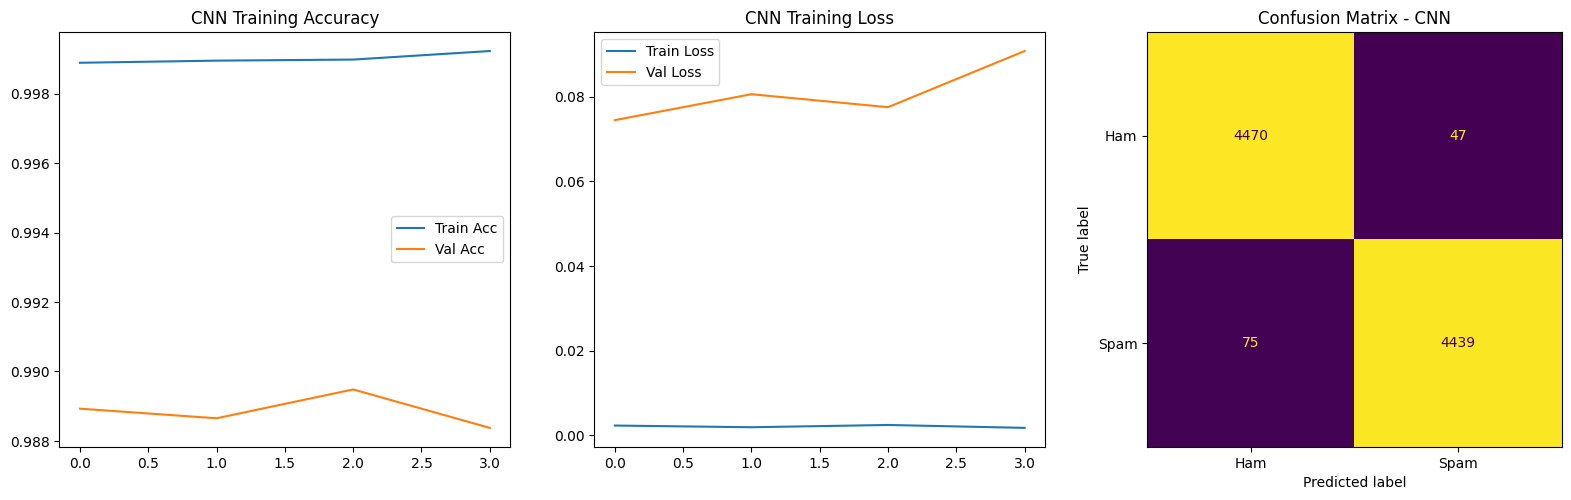

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
 CNN - VALIDATION SET RESULTS
 Accuracy: 0.8980
 F1-Score: 0.8979
Model saved: cnn_model.keras
Results saved: cnn_results.pkl


In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, confusion_matrix)
import matplotlib.pyplot as plt

y_prob_cnn = cnn_model.predict(X_test_pad).flatten()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)

print('=' * 50)
print(' CNN - TEST SET RESULTS')
print('=' * 50)
print(f' Accuracy:  {accuracy_score(y_test, y_pred_cnn):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_cnn):.4f}')
print(f' Recall:    {recall_score(y_test, y_pred_cnn):.4f}')
print(f' F1-Score:  {f1_score(y_test, y_pred_cnn):.4f}')
print(f' ROC-AUC:   {roc_auc_score(y_test, y_prob_cnn):.4f}')
print()
print(classification_report(y_test, y_pred_cnn, target_names=['Ham', 'Spam']))

import os
os.makedirs('../reports', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('CNN Training Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN Training Loss')
axes[1].legend()

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=['Ham', 'Spam']).plot(ax=axes[2], colorbar=False)
axes[2].set_title('Confusion Matrix - CNN')

plt.tight_layout()
plt.savefig('../reports/cnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Validation set ────────────────────────────────────────────────────────────
y_prob_cnn_val = cnn_model.predict(X_val_pad).flatten()
y_pred_cnn_val = (y_prob_cnn_val > 0.5).astype(int)

print('=' * 50)
print(' CNN - VALIDATION SET RESULTS')
print('=' * 50)
print(f' Accuracy: {accuracy_score(y_val, y_pred_cnn_val):.4f}')
print(f' F1-Score: {f1_score(y_val, y_pred_cnn_val):.4f}')

# ── Save model (.keras format avoids the deprecated .h5 warning in TF >= 2.13) ──
cnn_model.save('../models/cnn_model.keras')
print('Model saved: cnn_model.keras')

# ── Persist results for nb07 ──────────────────────────────────────────────────
import joblib
joblib.dump({
    'y_test':         y_test,         # int binary labels matching this split
    'y_pred_cnn':     y_pred_cnn,
    'y_prob_cnn':     y_prob_cnn,
    'y_val':          y_val,          # int binary labels
    'y_pred_cnn_val': y_pred_cnn_val,
    'y_prob_cnn_val': y_prob_cnn_val,
}, '../models/cnn_results.pkl')
print('Results saved: cnn_results.pkl')


## Deep Learning Model: Convolutional Neural Network (CNN)

The Convolutional Neural Network (CNN) model for text classification is defined, trained, and evaluated in the preceding cells (`c92ce50b`, `d4defb1b`, and `541631e8`).

This model uses an embedding layer, followed by multiple 1D convolutional layers, pooling layers, and dense layers to learn features from the text sequences and classify them as 'ham' or 'spam'. The model also incorporates `BatchNormalization` and `Dropout` for regularization and faster training.

Key steps:
- **Embedding Layer**: Converts words into dense vectors.
- **Conv1D Layers**: Extracts local features from the text sequences.
- **MaxPooling1D/GlobalMaxPooling1D**: Down-samples features and captures the most important ones.
- **Dense Layers**: Fully connected layers for classification.
- **Callbacks**: `EarlyStopping` and `ReduceLROnPlateau` are used during training to prevent overfitting and adjust the learning rate.
- **Class Weights**: Used to handle the class imbalance between 'ham' and 'spam' samples.

Results for the CNN model on both the test set and validation set, including accuracy, precision, recall, F1-score, and ROC-AUC, are displayed in cell `541631e8`, along with training plots and a confusion matrix.

## Machine Learning Model: Multinomial Naive Bayes

For the Machine Learning model, we will use a **Multinomial Naive Bayes classifier**. This is a probabilistic classifier often used for text classification tasks, particularly with count-based features (like word counts or TF-IDF).

We will build a `Pipeline` that first transforms the text data using `CountVectorizer` followed by `TfidfTransformer`, and then applies the `MultinomialNB` classifier. This approach is standard for traditional ML models in NLP.

Steps involved:
1.  **Feature Extraction**: Convert raw text into numerical features using `CountVectorizer` (to get word counts) and `TfidfTransformer` (to weight words by their importance).
2.  **Model Training**: Train the Multinomial Naive Bayes model on the transformed training data.
3.  **Model Evaluation**: Evaluate the trained model's performance using metrics like accuracy, precision, recall, and F1-score on the test and validation datasets.
4.  **Save Model**: Persist the trained model and its evaluation results.

Training Multinomial Naive Bayes model...
Training complete!

 Multinomial Naive Bayes - TEST SET RESULTS
 Accuracy:  0.9602
 Precision: 0.9410
 Recall:    0.9821
 F1-Score:  0.9611
 ROC-AUC:   0.9962

              precision    recall  f1-score   support

         Ham       0.98      0.94      0.96      4517
        Spam       0.94      0.98      0.96      4514

    accuracy                           0.96      9031
   macro avg       0.96      0.96      0.96      9031
weighted avg       0.96      0.96      0.96      9031



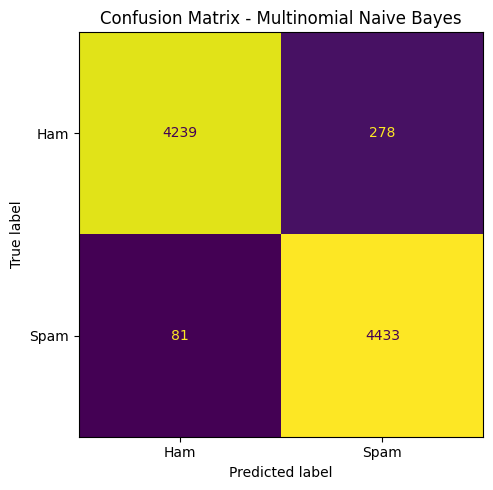


 Multinomial Naive Bayes - VALIDATION SET RESULTS
 Accuracy: 0.7385
 F1-Score: 0.7546

Model saved: ../models/multinomial_nb_model.pkl
Results saved: ../models/nb_results.pkl


In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, confusion_matrix)
import joblib
import matplotlib.pyplot as plt
import numpy as np

# Define the pipeline for the Naive Bayes classifier
nb_model_pipeline = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', MultinomialNB()),
])

print("Training Multinomial Naive Bayes model...")
nb_model_pipeline.fit(X_train, y_train)
print("Training complete!")

# Predict on the test set
y_pred_nb = nb_model_pipeline.predict(X_test)
y_prob_nb = nb_model_pipeline.predict_proba(X_test)[:, 1] # Probability of spam

print('\n' + '=' * 50)
print(' Multinomial Naive Bayes - TEST SET RESULTS')
print('=' * 50)
print(f' Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_nb):.4f}')
print(f' Recall:    {recall_score(y_test, y_pred_nb):.4f}')
print(f' F1-Score:  {f1_score(y_test, y_pred_nb):.4f}')
print(f' ROC-AUC:   {roc_auc_score(y_test, y_prob_nb):.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

# Plot confusion matrix for Naive Bayes
fig_nb, ax_nb = plt.subplots(figsize=(6, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(ax=ax_nb, colorbar=False)
ax_nb.set_title('Confusion Matrix - Multinomial Naive Bayes')
plt.tight_layout()
plt.savefig('../reports/nb_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate on validation set
y_pred_nb_val = nb_model_pipeline.predict(X_val)
y_prob_nb_val = nb_model_pipeline.predict_proba(X_val)[:, 1]

print('\n' + '=' * 50)
print(' Multinomial Naive Bayes - VALIDATION SET RESULTS')
print('=' * 50)
print(f' Accuracy: {accuracy_score(y_val, y_pred_nb_val):.4f}')
print(f' F1-Score: {f1_score(y_val, y_pred_nb_val):.4f}')

# Save the Naive Bayes model
joblib.dump(nb_model_pipeline, '../models/multinomial_nb_model.pkl')
print('\nModel saved: ../models/multinomial_nb_model.pkl')

# Persist results for comparison (e.g., in nb07)
joblib.dump({
    'y_test':         y_test,
    'y_pred_nb':      y_pred_nb,
    'y_prob_nb':      y_prob_nb,
    'y_val':          y_val,
    'y_pred_nb_val':  y_pred_nb_val,
    'y_prob_nb_val':  y_prob_nb_val,
}, '../models/nb_results.pkl')
print('Results saved: ../models/nb_results.pkl')